# Bureau d'Analyse Terrestre — Klaxo-3

Notebook principal : Phases 1 à 12 du projet OVNI.

Fichier source : `releves_klaxo3.csv` (sans en-têtes, 11 colonnes).

Exécuter toutes les cellules dans l'ordre (Run All).

## Setup — imports et constantes

In [26]:
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

FICHIER_SOURCE = "releves_klaxo3.csv"
FICHIER_NETTOYE = "releves_klaxo3_nettoye.csv"

COLONNES = [
    "datetime", "city", "state", "country", "shape",
    "duration_seconds", "duration_hours_min", "comments",
    "date_posted", "latitude", "longitude",
]

CANULAR_PATTERNS = [
    r"(?i)possible hoax",
    r"(?i)student report",
    r"(?i)editorial comment",
    r"(?i)does not look like a ufo",
]

---
# Phase 1 — Ouvrir la caisse

Objectif : charger la transmission et rendre **3 nombres cohérents**.
- Lignes dans le fichier
- Lignes chargées
- Lignes traitées à part (mal formées)

In [27]:
lignes_a_part = []

def bad_handler(bad_line):
    lignes_a_part.append(bad_line)
    return None

df_brut = pd.read_csv(
    FICHIER_SOURCE,
    header=None,
    names=COLONNES,
    engine="python",
    on_bad_lines=bad_handler,
)

nb_lignes_fichier = sum(1 for _ in open(FICHIER_SOURCE, encoding="utf-8", errors="replace"))
nb_chargees = len(df_brut)
nb_a_part = len(lignes_a_part)

print(f"Lignes dans le fichier      : {nb_lignes_fichier:,}")
print(f"Lignes chargées             : {nb_chargees:,}")
print(f"Lignes traitées à part      : {nb_a_part:,}")
print(f"Vérification (chargées+à part): {nb_chargees + nb_a_part:,}")

Lignes dans le fichier      : 88,875
Lignes chargées             : 88,679
Lignes traitées à part      : 196
Vérification (chargées+à part): 88,875


In [28]:
if lignes_a_part:
    ex = lignes_a_part[0]
    print("Exemple de ligne traitée à part :")
    print(f"  Champs détectés : {len(ex)} (attendu : 11)")
    print(f"  Contenu : {ex}")
    print("  Problème : virgules en trop / champs vides décalés.")

Exemple de ligne traitée à part :
  Champs détectés : 12 (attendu : 11)
  Contenu : ['10/1/2006 12:00', '', '', '', '', '0', '', '', '((EDITORIAL COMMENT ABOUT THE UFO PHENOMEN))  ufo+alien+reptiles', '10/30/2006', '0', '0']
  Problème : virgules en trop / champs vides décalés.


### Premier regard (exploration)

In [29]:
print(f"Dimensions : {df_brut.shape[0]:,} lignes x {df_brut.shape[1]} colonnes")
display(df_brut.head(10))

Dimensions : 88,679 lignes x 11 colonnes


,datetime,city,state,country,shape,duration_seconds,duration_hours_min,comments,date_posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611
5,10/10/1961 19:00,bristol,tn,us,sphere,300,5 minutes,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.5950000,-82.188889
6,10/10/1965 21:00,penarth (uk/wales),NaN,gb,circle,180,about 3 mins,penarth uk circle 3mins stayed 30ft above m...,2/14/2006,51.434722,-3.180000
7,10/10/1965 23:45,norwalk,ct,us,disk,1200,20 minutes,A bright orange color changing to reddish colo...,10/2/1999,41.1175000,-73.408333
8,10/10/1966 20:00,pell city,al,us,disk,180,3 minutes,Strobe Lighted disk shape object observed clos...,3/19/2009,33.5861111,-86.286111
9,10/10/1966 21:00,live oak,fl,us,disk,120,several minutes,Saucer zaps energy from powerline as my pregna...,5/11/2005,30.2947222,-82.984167


In [30]:
missing = pd.DataFrame({
    "colonne": df_brut.columns,
    "nb_nan": df_brut.isna().sum().values,
    "pct_nan": (df_brut.isna().sum().values / len(df_brut) * 100).round(2),
}).sort_values("nb_nan", ascending=False)
display(missing[missing["nb_nan"] > 0])

,colonne,nb_nan,pct_nan
3,country,12365,13.94
2,state,7409,8.35
6,duration_hours_min,3019,3.40
4,shape,2922,3.30
7,comments,35,0.04
5,duration_seconds,2,0.00


---
# Phase 2 — Conversion de types

**Aucune ligne supprimée** — on convertit chaque champ au bon type et on compte les anomalies.

In [31]:
df = df_brut.copy()

df["duration_seconds"] = pd.to_numeric(df["duration_seconds"], errors="coerce")
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["date_posted"] = pd.to_datetime(df["date_posted"], errors="coerce")

for col in ["city", "state", "country", "shape", "duration_hours_min", "comments"]:
    df[col] = df[col].astype("string")

print(f"Lignes conservées : {len(df):,} (aucune suppression)")
df[["duration_seconds", "latitude", "longitude"]].describe()

Lignes conservées : 88,679 (aucune suppression)


,duration_seconds,latitude,longitude
count,8.867400e+04,88678.000000,88679.000000
mean,8.391920e+03,37.453081,-85.021836
std,5.911567e+05,11.572496,41.421744
min,0.000000e+00,-82.862752,-176.658056
25%,1.500000e+01,34.035000,-112.073333
50%,1.200000e+02,39.233333,-87.650000
75%,6.000000e+02,42.717836,-77.769738
max,9.783600e+07,72.700000,178.441900


In [32]:
anomalies_rows = []

def add_anomaly(nom, mask, source, exemple_fn):
    n = int(mask.sum())
    ex = exemple_fn() if n > 0 else "—"
    anomalies_rows.append({
        "anomalie": nom, "nombre": n,
        "pct": round(n / len(df) * 100, 2), "source": source, "exemple": ex,
    })

ville_vide = df["city"].isna() | (df["city"].str.strip() == "")
add_anomaly("Ville vide", ville_vide, "Témoin / transmission",
            lambda: df.loc[ville_vide, ["city", "state"]].head(1).to_dict())

coords_zero = (df["latitude"] == 0) & (df["longitude"] == 0)
add_anomaly("Coordonnées (0, 0)", coords_zero, "Capteur / géolocalisation",
            lambda: df.loc[coords_zero, ["city", "latitude", "longitude"]].head(1).to_dict())

duree_zero = df["duration_seconds"] == 0
add_anomaly("Durée = 0 seconde", duree_zero, "Service de transmission",
            lambda: df.loc[duree_zero, ["duration_seconds", "duration_hours_min"]].head(1).to_dict())

datetime_invalid = df["datetime"].isna()
add_anomaly("Date d'observation illisible", datetime_invalid, "Témoin / transmission",
            lambda: str(df_brut.loc[datetime_invalid].head(1)["datetime"].values[0]))

pays_vide = df["country"].isna() | (df["country"].str.strip() == "")
add_anomaly("Pays vide", pays_vide, "Témoin",
            lambda: str(df.loc[pays_vide, "city"].head(1).values[0]))

anomalies = pd.DataFrame(anomalies_rows)
display(anomalies)

,anomalie,nombre,pct,source,exemple
0,Ville vide,0,0.00,Témoin / transmission,—
1,"Coordonnées (0, 0)",1494,1.68,Capteur / géolocalisation,"{'city': {19: 'willow beach'}, 'latitude': {19..."
2,Durée = 0 seconde,7027,7.92,Service de transmission,"{'duration_seconds': {65: 0.0}, 'duration_hour..."
3,Date d'observation illisible,1220,1.38,Témoin / transmission,10/10/2005 24:00
4,Pays vide,12365,13.94,Témoin,lackland afb


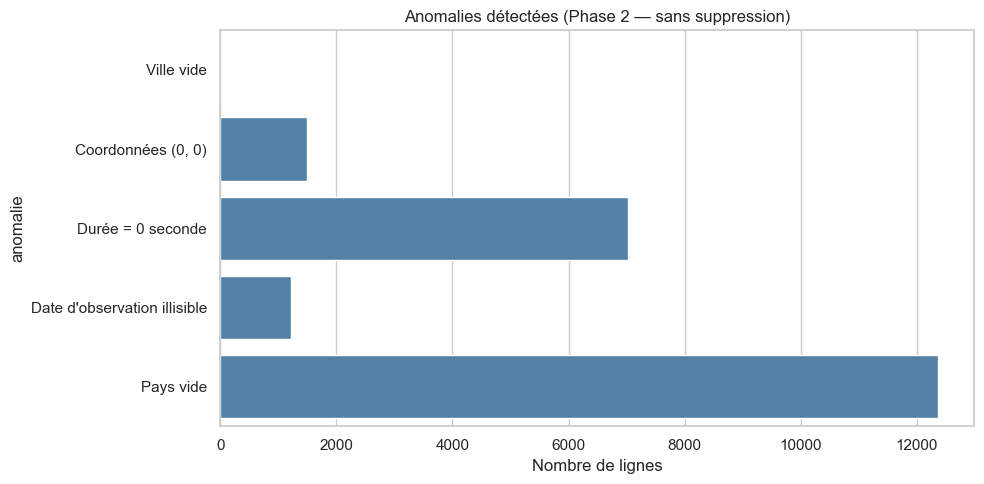

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=anomalies, x="nombre", y="anomalie", ax=ax, color="steelblue")
ax.set_title("Anomalies détectées (Phase 2 — sans suppression)")
ax.set_xlabel("Nombre de lignes")
plt.tight_layout()
plt.show()

---
# Phase 3 — Règle de canulars

**Règle :** un relevé est un canular si son commentaire contient une note NUFORC mentionnant un hoax, un rapport étudiant, un commentaire éditorial, ou indiquant que ce n'est pas un UFO.

**Limite :** la règle ne voit que ce que le modérateur a annoté — un canular sans note passe inaperçu.

In [34]:
comments = df["comments"].astype(str)
is_canular = pd.Series(False, index=df.index)
for pattern in CANULAR_PATTERNS:
    is_canular |= comments.str.contains(pattern, regex=True, na=False)

n_canular = int(is_canular.sum())
pct_canular = n_canular / len(df) * 100
print(f"Canulars détectés : {n_canular:,} ({pct_canular:.2f} %)")
display(df.loc[is_canular, ["datetime", "city", "shape", "comments"]].head(5))

Canulars détectés : 189 (0.21 %)


,datetime,city,shape,comments
216,2008-10-10 22:00:00,san diego,disk,low flying saucer in suburban area. ((NUFORC ...
658,1994-10-01 13:13:00,new york city,disk,a flying colorful disc above my car&#44 near E...
876,2006-10-01 12:00:00,flemington,cross,A plane shaped object that was silver with a y...
958,2008-10-01 19:12:00,bonham,egg,Silver egg shape over six houses. ((NUFORC No...
1751,2008-10-14 01:00:00,austin,sphere,black sphere with glowing ring around it. ((N...


---
# Phase 4 — Modèle (avec comments, avant correction fuite)

Random Forest sur 80 % train / 20 % test (jamais vus).

In [35]:
def preparer_features(data, avec_commentaires=False):
    X = data[["city", "state", "country", "shape", "duration_seconds", "latitude", "longitude"]].copy()
    X["duration_seconds"] = X["duration_seconds"].fillna(0)
    X["latitude"] = X["latitude"].fillna(0)
    X["longitude"] = X["longitude"].fillna(0)
    for col in ["city", "state", "country", "shape"]:
        X[col] = X[col].fillna("").astype(str)
    if avec_commentaires:
        X["comments"] = data["comments"].fillna("").astype(str)
    return X

def construire_modele(avec_commentaires=False):
    cat_cols = ["city", "state", "country", "shape"]
    num_cols = ["duration_seconds", "latitude", "longitude"]
    transformers = [
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="")),
            ("oh", OneHotEncoder(handle_unknown="ignore", max_categories=40)),
        ]), cat_cols),
        ("num", "passthrough", num_cols),
    ]
    if avec_commentaires:
        transformers.append(("txt", TfidfVectorizer(max_features=300, ngram_range=(1, 2)), "comments"))
    return Pipeline([
        ("prep", ColumnTransformer(transformers)),
        ("clf", RandomForestClassifier(n_estimators=80, max_depth=14, random_state=42,
                                       n_jobs=-1, class_weight="balanced")),
    ])

def entrainer_evaluer(data, y, avec_commentaires=False):
    X = preparer_features(data, avec_commentaires)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y.astype(int), test_size=0.2, random_state=42, stratify=y
    )
    modele = construire_modele(avec_commentaires)
    modele.fit(X_train, y_train)
    pred = modele.predict(X_test)
    return {
        "recall": recall_score(y_test, pred, zero_division=0),
        "precision": precision_score(y_test, pred, zero_division=0),
        "accuracy": accuracy_score(y_test, pred),
        "y_test": y_test, "pred": pred,
    }

In [36]:
metriques_avant = entrainer_evaluer(df, is_canular, avec_commentaires=True)
print(f"Rappel    : {metriques_avant['recall']*100:.1f} %")
print(f"Précision : {metriques_avant['precision']*100:.1f} %")
print(f"Accuracy  : {metriques_avant['accuracy']*100:.1f} %")

Rappel    : 94.7 %
Précision : 20.3 %
Accuracy  : 99.2 %


---
# Phase 5 — Fuite de données

| Colonne | Qui écrit | Quand | Savait si canular ? |
|---|---|---|---|
| datetime | Témoin | Soir de l'observation | Non |
| city/state/country | Témoin | Observation | Non |
| shape | Témoin | Observation | Non |
| duration_seconds | Service transmission | Traitement | Non |
| latitude/longitude | Capteur Klaxo-3 | Observation | Non |
| comments | Témoin + employé Bureau | Mixte | **Oui** |
| date_posted | Employé Bureau | Semaines après | **Oui** |

On retire `comments` et `date_posted` du modèle.

In [37]:
metriques_apres = entrainer_evaluer(df, is_canular, avec_commentaires=False)

comparaison = pd.DataFrame({
    "Métrique": ["Rappel", "Précision"],
    "Avant (avec comments)": [
        f"{metriques_avant['recall']*100:.1f} %",
        f"{metriques_avant['precision']*100:.1f} %",
    ],
    "Après (sans fuite)": [
        f"{metriques_apres['recall']*100:.1f} %",
        f"{metriques_apres['precision']*100:.1f} %",
    ],
})
display(comparaison)

print("\nExplication : le modèle « avant » lisait les notes du modérateur dans comments.")
print("L'employé savait déjà si c'était un canular — c'est de la triche.")
print("Sans comments, le modèle est honnête mais attrape moins de canulars.")

,Métrique,Avant (avec comments),Après (sans fuite)
0,Rappel,94.7 %,21.1 %
1,Précision,20.3 %,0.5 %



Explication : le modèle « avant » lisait les notes du modérateur dans comments.
L'employé savait déjà si c'était un canular — c'est de la triche.
Sans comments, le modèle est honnête mais attrape moins de canulars.


---
# Phase 6 — Baseline stagiaire

Le stagiaire répond toujours « pas un canular ». Son accuracy est élevée parce qu'il ignore tous les canulars — d'où l'importance du **rappel** et de la **précision**.

In [38]:
y_test = metriques_apres["y_test"]
pred_stagiaire = np.zeros_like(y_test)

acc_stagiaire = accuracy_score(y_test, pred_stagiaire)
acc_modele = metriques_apres["accuracy"]

print(f"Stagiaire (toujours pas canular) : {acc_stagiaire*100:.1f} % accuracy")
print(f"Notre modèle (sans fuite)        : {acc_modele*100:.1f} % accuracy")
print(f"Rappel modèle                    : {metriques_apres['recall']*100:.1f} %")
print(f"Précision modèle                 : {metriques_apres['precision']*100:.1f} %")

Stagiaire (toujours pas canular) : 99.8 % accuracy
Notre modèle (sans fuite)        : 90.2 % accuracy
Rappel modèle                    : 21.1 %
Précision modèle                 : 0.5 %


---
# Phase 7 — Plusieurs témoins, un seul événement

**Règle événement :** même heure (arrondie) + même ville.

Colonnes : `datetime`, `city`. Tous les témoins d'un événement restent du même côté (train ou test).

In [ ]:
df["event_key"] = (
    df["datetime"].dt.floor("h").astype(str) + "|" +
    df["city"].fillna("").astype(str).str.lower().str.strip()
)

event_counts = df.groupby("event_key").size()
events_multi = event_counts[event_counts > 1]
print(f"Événements signalés par > 1 témoin : {len(events_multi):,}")
print(f"Plus gros événement (témoins)      : {event_counts.max():,}")

mask_dup_comment = df.duplicated(subset=["comments"], keep=False) & df["comments"].notna()
print(f"Relevés commentaire dupliqué (mot pour mot) : {mask_dup_comment.sum():,}")
print("Traitement : conservés, regroupés par event_key si même datetime+ville.")

_, idx_test_old = train_test_split(
    df.index, test_size=0.2, random_state=42, stratify=is_canular
)
train_old = set(df.index.difference(idx_test_old))
test_old = set(idx_test_old)

def event_chevauche(key):
    idxs = df.index[df["event_key"] == key]
    tr = sum(i in train_old for i in idxs)
    te = sum(i in test_old for i in idxs)
    return tr > 0 and te > 0

events_split_old = sum(event_chevauche(k) for k in events_multi.index)
rows_split_old = sum(
    len(df.index[df["event_key"] == k])
    for k in events_multi.index
    if event_chevauche(k)
)
print(f"Événements multi-témoins à cheval (ancienne découpe) : {events_split_old:,}")
print(f"Relevés à cheval (ancienne découpe aléatoire)        : {rows_split_old:,}")

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_ev, test_idx_ev = next(gss.split(df, is_canular, groups=df["event_key"]))

ex_key = event_counts.idxmax()
print("Exemple — tous les témoins du plus gros événement :")
display(df.loc[df["event_key"] == ex_key, ["datetime", "city", "shape", "comments"]].head(10))

---
# Phase 8 — L'ordre des choses

Découpe sur **`datetime`** (observation), pas `date_posted`. Train = passé, test = futur. Les événements restent entiers.

In [ ]:
event_time = df.groupby("event_key")["datetime"].min().sort_values()
keys = event_time.index.tolist()
cut = int(len(keys) * 0.8)
train_events_t = set(keys[:cut])
test_events_t = set(keys[cut:])

train_mask = df["event_key"].isin(train_events_t)
test_mask = df["event_key"].isin(test_events_t)

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()
y_train = is_canular[train_mask].astype(int)
y_test = is_canular[test_mask].astype(int)

date_coupe = event_time.iloc[cut - 1]
print(f"Date de coupure : {date_coupe}")
print(f"Relevés train : {len(df_train):,} | test : {len(df_test):,}")
print(f"Canulars train : {y_train.mean()*100:.3f} % | test : {y_test.mean()*100:.3f} %")

---
# Phase 9 — Les cases vides

Comparer canulars avec/sans trou sur les 3 colonnes les plus trouées. Traitement : `UNKNOWN` + indicateur `_missing`.

In [ ]:
cols_trouees = ["country", "state", "shape"]
rows = []
for col in cols_trouees:
    trou = df[col].isna() | (df[col].astype(str).str.strip() == "")
    rows.append({
        "colonne": col,
        "pct_canular_avec_trou": round(is_canular[trou].mean() * 100, 3),
        "pct_canular_sans_trou": round(is_canular[~trou].mean() * 100, 3),
    })
display(pd.DataFrame(rows))
print("Traitement : UNKNOWN + colonne binaire _missing (on garde la trace du trou).")

---
# Phase 11 — Durée utilisable

Compléter `duration_seconds` via `duration_hours_min` quand seconds = 0.

In [ ]:
def parse_duree_texte(text):
    if pd.isna(text):
        return np.nan
    s = str(text).lower().strip()
    if not s:
        return np.nan
    total, found = 0.0, False
    for val, unit in re.findall(
        r"(\d+(?:\.\d+)?)\s*(sec|secs|second|seconds|min|mins|minute|minutes|hr|hrs|hour|hours|h)",
        s,
    ):
        found = True
        n = float(val)
        if unit.startswith("sec"):
            total += n
        elif unit.startswith("min"):
            total += n * 60
        else:
            total += n * 3600
    return total if found else np.nan

df["duration_usable"] = df["duration_seconds"].copy()
mask_zero = df["duration_usable"].fillna(0) == 0
df.loc[mask_zero, "duration_usable"] = df.loc[mask_zero, "duration_hours_min"].apply(parse_duree_texte)

contradiction = (
    (df["duration_seconds"].fillna(0) == 0)
    & df["duration_hours_min"].notna()
    & (df["duration_hours_min"].astype(str).str.strip() != "")
    & df["duration_usable"].notna()
)
inutilisable = df["duration_usable"].isna() | (df["duration_usable"] <= 0)
plus_1_jour = df["duration_usable"] > 86400

print(f"Inutilisable après traitement : {inutilisable.sum():,}")
print(f"Contradictions (0 sec vs texte) : {contradiction.sum():,}")
print(f"Médiane (s) : {df.loc[df['duration_usable']>0,'duration_usable'].median():,.0f}")
print(f"> 1 jour : {plus_1_jour.sum():,}")
display(df.nlargest(3, "duration_usable")[["datetime","city","duration_seconds","duration_hours_min","duration_usable"]])
df["duration_usable"] = df["duration_usable"].clip(upper=86400)
df_train["duration_usable"] = df.loc[df_train.index, "duration_usable"]
df_test["duration_usable"] = df.loc[df_test.index, "duration_usable"]
print("Décision : plafond à 86400 s (1 jour) pour limiter les aberrations.")

---
# Phase 12 — Ville et heure

In [ ]:
city_counts = df['city'].fillna('').astype(str).str.lower().str.strip().value_counts()
villes_1_fois = (city_counts == 1).sum()
print(f"Villes uniques : {df['city'].nunique():,} | n'apparaissant qu'une fois : {villes_1_fois:,}")
print("Règle villes : >= 5 occurrences sinon OTHER.")

def circ_dist(h1, h2):
    d = abs(h1 - h2)
    return min(d, 24 - d)

def enc_dist(h1, h2):
    return math.sqrt(
        (math.sin(2 * math.pi * h1 / 24) - math.sin(2 * math.pi * h2 / 24)) ** 2
        + (math.cos(2 * math.pi * h1 / 24) - math.cos(2 * math.pi * h2 / 24)) ** 2
    )

print(f"Distance linéaire 23h-0h : {circ_dist(23,0)} | 23h-20h : {circ_dist(23,20)}")
print(f"Distance sin/cos 23h-0h : {enc_dist(23,0):.3f} | 23h-20h : {enc_dist(23,20):.3f}")

shape_counts = df['shape'].fillna('').astype(str).str.lower().str.strip().value_counts()
shape_keep = set(shape_counts[shape_counts >= 10].index)
print(f"Formes gardées (>=10) + OTHER : {len(shape_keep)+1}")
print(f"Colonnes brutes ~7 | après encodage ~150-300 (vs ~22000 OneHot ville brute)")

---
# Phase 10 — Pipeline propre

Fit sur train seulement. Un relevé entre, une prédiction sort.

In [ ]:
class FeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        city = X['city'].fillna('').astype(str).str.lower().str.strip()
        self.city_classes_ = set(city.value_counts()[city.value_counts() >= 5].index)
        shape = X['shape'].fillna('').astype(str).str.lower().str.strip()
        self.shape_classes_ = set(shape.value_counts()[shape.value_counts() >= 10].index)
        self.state_classes_ = set(
            X['state'].fillna('UNKNOWN').astype(str).str.strip().value_counts().index
        )
        self.country_classes_ = set(
            X['country'].fillna('UNKNOWN').astype(str).str.strip().value_counts().index
        )
        sample = self.transform(X.head(500))
        self.columns_ = sample.columns.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        out = pd.DataFrame(index=X.index)
        out['duration_usable'] = X['duration_usable'].fillna(0)
        out['latitude'] = X['latitude'].fillna(0)
        out['longitude'] = X['longitude'].fillna(0)
        h = X['datetime'].dt.hour.fillna(0).astype(int)
        out['hour_sin'] = np.sin(2 * np.pi * h / 24)
        out['hour_cos'] = np.cos(2 * np.pi * h / 24)
        for col in ['country', 'state', 'shape']:
            trou = X[col].isna() | (X[col].astype(str).str.strip() == '')
            out[f'{col}_missing'] = trou.astype(int)
        state = X['state'].fillna('UNKNOWN').astype(str).str.strip()
        country = X['country'].fillna('UNKNOWN').astype(str).str.strip()
        city = X['city'].fillna('').astype(str).str.lower().str.strip()
        shape = X['shape'].fillna('').astype(str).str.lower().str.strip()
        city_grp = city.where(city.isin(self.city_classes_), 'OTHER')
        shape_grp = shape.where(shape.isin(self.shape_classes_), 'OTHER')
        state_grp = state.where(state.isin(self.state_classes_), 'OTHER')
        country_grp = country.where(country.isin(self.country_classes_), 'OTHER')
        out = pd.concat(
            [
                out,
                pd.get_dummies(city_grp, prefix='city'),
                pd.get_dummies(shape_grp, prefix='shape'),
                pd.get_dummies(state_grp, prefix='state'),
                pd.get_dummies(country_grp, prefix='country'),
            ],
            axis=1,
        )
        if hasattr(self, 'columns_'):
            out = out.reindex(columns=self.columns_, fill_value=0)
        return out

fb = FeatureBuilder()
X_tr = fb.fit_transform(df_train)
X_te = fb.transform(df_test)
clf_p10 = RandomForestClassifier(
    n_estimators=80, max_depth=14, random_state=42, class_weight='balanced', n_jobs=-1
)
clf_p10.fit(X_tr, y_train)
pred_p10 = clf_p10.predict(X_te)
print(f'Canulars train {y_train.mean()*100:.3f}% | test {y_test.mean()*100:.3f}%')
print(f'Rappel    : {recall_score(y_test, pred_p10, zero_division=0)*100:.1f}%')
print(f'Précision : {precision_score(y_test, pred_p10, zero_division=0)*100:.1f}%')
print(f'Colonnes  : {X_tr.shape[1]}')

In [ ]:
ligne_neuve = pd.DataFrame([{
    'datetime': pd.Timestamp('2010-06-15 23:30:00'),
    'city': 'paris',
    'state': '',
    'country': '',
    'shape': 'light',
    'duration_seconds': 0,
    'duration_hours_min': '5 minutes',
    'comments': 'Lumière bizarre.',
    'date_posted': pd.Timestamp('2010-07-01'),
    'latitude': 48.85,
    'longitude': 2.35,
    'duration_usable': 300,
}])
pred_neuve = clf_p10.predict(fb.transform(ligne_neuve))[0]
print('Prédiction relevé inventé (canular?) :', bool(pred_neuve))

In [ ]:
X_old_tr, X_old_te, y_old_tr, y_old_te = train_test_split(
    preparer_features(df, avec_commentaires=False),
    is_canular.astype(int),
    test_size=0.2,
    random_state=42,
    stratify=is_canular,
)
old = construire_modele(avec_commentaires=False)
old.fit(X_old_tr, y_old_tr)
p_old = old.predict(X_old_te)
display(pd.DataFrame({
    'Méthode': ['Split aléatoire (Ph.4/5)', 'Événement+temps+pipeline (Ph.7-10)'],
    'Rappel': [
        f"{recall_score(y_old_te, p_old, zero_division=0)*100:.1f}%",
        f"{recall_score(y_test, pred_p10, zero_division=0)*100:.1f}%",
    ],
    'Précision': [
        f"{precision_score(y_old_te, p_old, zero_division=0)*100:.1f}%",
        f"{precision_score(y_test, pred_p10, zero_division=0)*100:.1f}%",
    ],
}))

---
# Annexe — Nettoyage pour cartographie (hors sujet noté)

Filtre les relevés exploitables pour une carte : lieu valide + durée > 0.

In [39]:
lieu_invalide = (
    df["city"].isna() | (df["city"].str.strip() == "")
    | ((df["latitude"] == 0) & (df["longitude"] == 0))
)
temps_invalide = df["duration_seconds"] == 0
ok = ~lieu_invalide & ~temps_invalide

print(f"Lignes exploitables : {ok.sum():,} / {len(df):,}")
print(f"Lignes à supprimer  : {(~ok).sum():,}")

Lignes exploitables : 80,334 / 88,679
Lignes à supprimer  : 8,345


In [40]:
df_clean = df[ok].copy()
df_clean.to_csv(FICHIER_NETTOYE, index=False)
print(f"Export : {FICHIER_NETTOYE} ({len(df_clean):,} lignes)")

Export : releves_klaxo3_nettoye.csv (80,334 lignes)


### Synthèse visuelle (exploration qualité)

C:\Users\secre\AppData\Local\Temp\ipykernel_34716\970790035.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories.index, y=categories.values, ax=ax, palette="Set2")


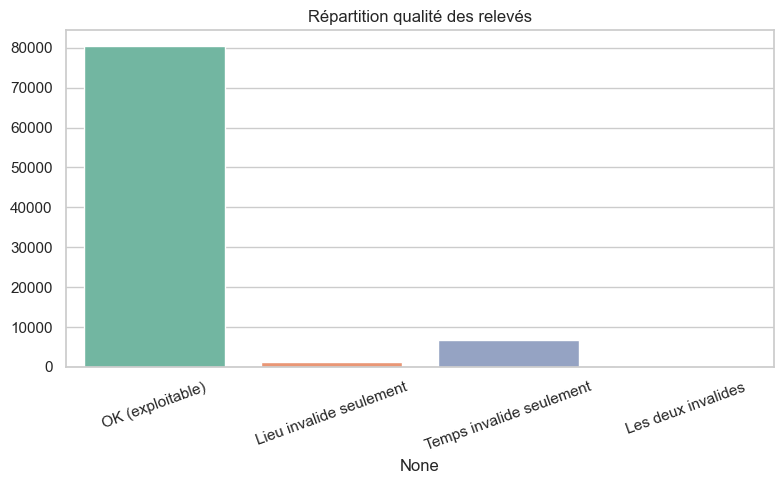

In [41]:
categories = pd.Series({
    "OK (exploitable)": ok.sum(),
    "Lieu invalide seulement": (lieu_invalide & ~temps_invalide).sum(),
    "Temps invalide seulement": (~lieu_invalide & temps_invalide).sum(),
    "Les deux invalides": (lieu_invalide & temps_invalide).sum(),
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=categories.index, y=categories.values, ax=ax, palette="Set2")
ax.set_title("Répartition qualité des relevés")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()